# 2. Demographic Effects on Pitch: Age and Gender

This notebook investigates how fundamental frequency (F0) varies as a function of:

- Gender
- Age (continuous)
- Age × gender interaction

The goal is descriptive and inferential characterization
of demographic structure in conversational pitch.


## 2.0 Setup

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr
from pathlib import Path

sns.set(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 14

### Data Sources

We merge two independently generated data products:

1. F0 Feature Table: Conversation-level acoustic features computed over entire WAV files.

2. Vox-Profile Outputs: File-level demographic and affective estimates produced using Vox-Profile.

Merging is performed using the full WAV path as a stable key.


In [2]:
F0_CSV = Path("/home/ahallur1/spear/Seamless_Experiments/F0/seamless_f0_features.csv")
assert F0_CSV.exists()

df_f0 = pd.read_csv(F0_CSV)
print(f"F0 rows: {len(df_f0):,}")

F0 rows: 129,215


In [3]:
VOX_CSV = Path(
    "/home/ahallur1/spear/Vox_Profile/vox-profile-release/csv_shards/participant_vox_profile_file_level.csv"
)
assert VOX_CSV.exists()

df_vox = pd.read_csv(VOX_CSV)
print(f"Vox-profile rows: {len(df_vox):,}")
df_vox.head()

Vox-profile rows: 124,184


,wav_path,age_years,gender,gender_confidence,arousal,valence,dominance,num_chunks_used,total_speech_sec,used_only_15s_chunks
0,/export/fs06/corpora8/seamless_interaction/dat...,15.582508,male,1.0,0.463526,0.508113,0.470249,11,165.0,1
1,/export/fs06/corpora8/seamless_interaction/dat...,31.372758,male,1.0,0.397141,0.634210,0.480438,3,45.0,1
2,/export/fs06/corpora8/seamless_interaction/dat...,26.758918,male,1.0,0.558911,0.682773,0.539479,8,120.0,1
3,/export/fs06/corpora8/seamless_interaction/dat...,26.633680,male,1.0,0.535294,0.557190,0.550871,4,60.0,1
4,/export/fs06/corpora8/seamless_interaction/dat...,31.828518,male,1.0,0.495486,0.597825,0.555794,7,105.0,1


In [4]:
df = df_f0.merge(
    df_vox,
    on="wav_path",
    how="left",
    validate="one_to_one"
)

print(f"Merged rows: {len(df):,}")

Merged rows: 129,215


In [5]:
df_dem = df[
    (df["status"] == "OK") &
    (df["age_years"].notna()) &
    (df["gender"].notna()) &
    (df["gender_confidence"] >= 0.5)
].copy()

print(f"Usable rows after filtering: {len(df_dem):,}")
df_dem["gender"].value_counts()

Usable rows after filtering: 121,813


gender
male      65214
female    56599
Name: count, dtype: int64

In [6]:
def age_bin(age):
    if pd.isna(age):
        return np.nan
    if age < 18:
        return np.nan  # unstable / out-of-distribution
    elif age < 30:
        return "18-29"
    elif age < 60:
        return "30-59"
    else:
        return "60+"

df_dem = df_dem.copy()
df_dem["age_group"] = df_dem["age_years"].apply(age_bin)

# Keep only valid age bins
df_dem_age = df_dem.dropna(subset=["age_group"]).copy()

print("Age group counts:")
display(df_dem_age["age_group"].value_counts())


Age group counts:


age_group
30-59    63983
18-29    47798
60+       6252
Name: count, dtype: int64

## 2.1 Gender Differences in Conversational Pitch

Mean F0 is the most robust and interpretable prosodic correlate of gender.

We examine:
- Raw mean F0
- Robust 10–90 mean F0
- Robust 25–75 mean F0

to confirm consistency across definitions.


In [7]:
metrics = [
    "f0_mean_raw",
    "f0_mean_p10_p90",
    "f0_mean_p25_p75"
]

gender_means = (
    df_dem
    .groupby("gender")[metrics]
    .agg(["mean", "std"])
)

gender_means

f0_mean_raw            f0_mean_p10_p90            f0_mean_p25_p75  \
              mean        std            mean        std            mean   
gender                                                                     
female  207.567912  28.763563      202.674497  28.799985      199.643552   
male    133.357461  23.702625      125.749461  23.376324      123.097234   

                   
              std  
gender             
female  28.263938  
male    22.723887

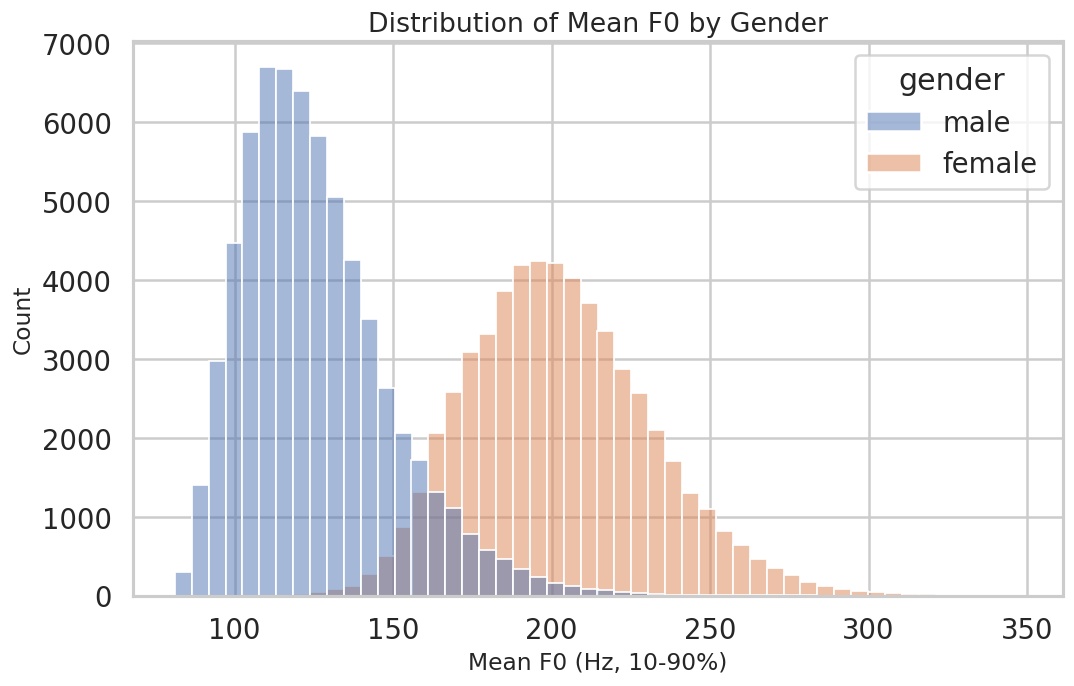

In [8]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_dem,
    x="f0_mean_p10_p90",
    hue="gender",
    bins=50,
    stat="count",
    common_norm=False,
    alpha=0.5
)

plt.xlabel("Mean F0 (Hz, 10-90%)")
plt.title("Distribution of Mean F0 by Gender")
plt.show()

## 2.2 Age Effects

In [10]:
# plt.figure(figsize=(9, 6))

# sns.scatterplot(
#     data=df_dem,
#     x="age_years",
#     y="f0_mean_p10_p90",
#     hue="gender",
#     alpha=0.3
# )

# for gender, color in zip(df_dem["gender"].unique(), ["tab:blue", "tab:orange"]):
#     sns.regplot(
#         data=df_dem[df_dem["gender"] == gender],
#         x="age_years",
#         y="f0_mean_p10_p90",
#         scatter=False,
#         lowess=True,
#         color=color,
#         label=f"{gender} trend"
#     )

# plt.xlabel("Age (years)")
# plt.ylabel("Mean F0 (Hz, 10–90%)")
# plt.title("Age vs Mean Conversational Pitch")
# plt.legend()
# plt.tight_layout()
# plt.show()

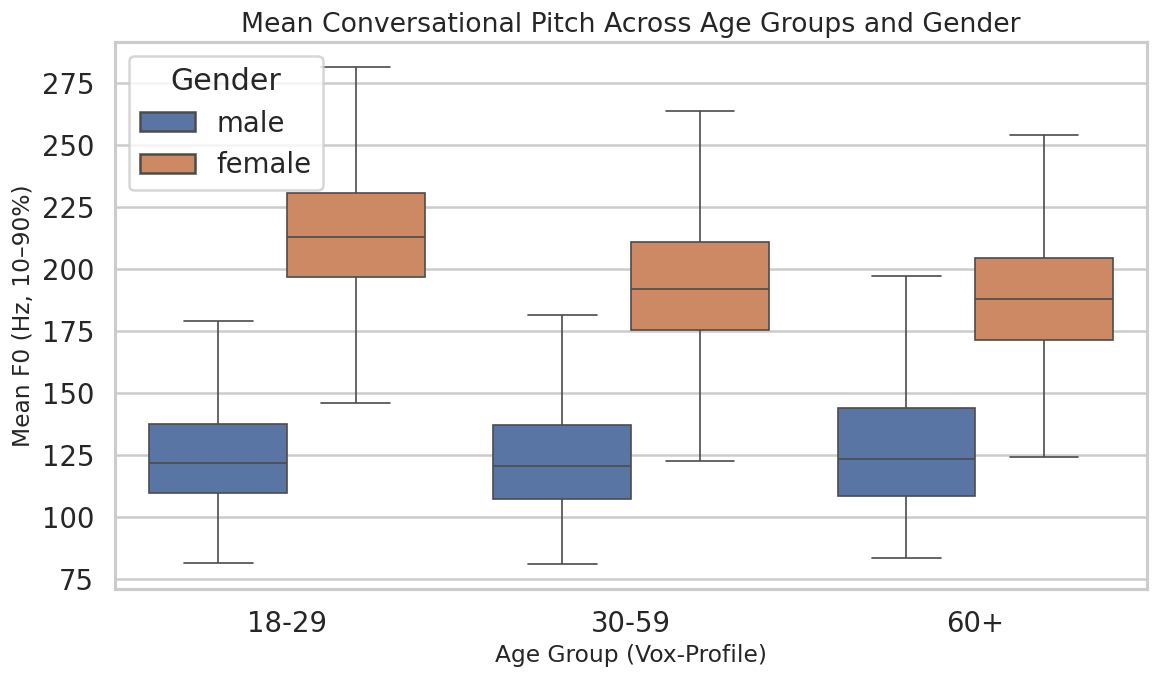

In [11]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_dem_age,
    x="age_group",
    y="f0_mean_p10_p90",
    hue="gender",
    showfliers=False
)

plt.xlabel("Age Group (Vox-Profile)")
plt.ylabel("Mean F0 (Hz, 10–90%)")
plt.title("Mean Conversational Pitch Across Age Groups and Gender")
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

/tmp/ipykernel_47084/3753491084.py:3: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  sns.pointplot(


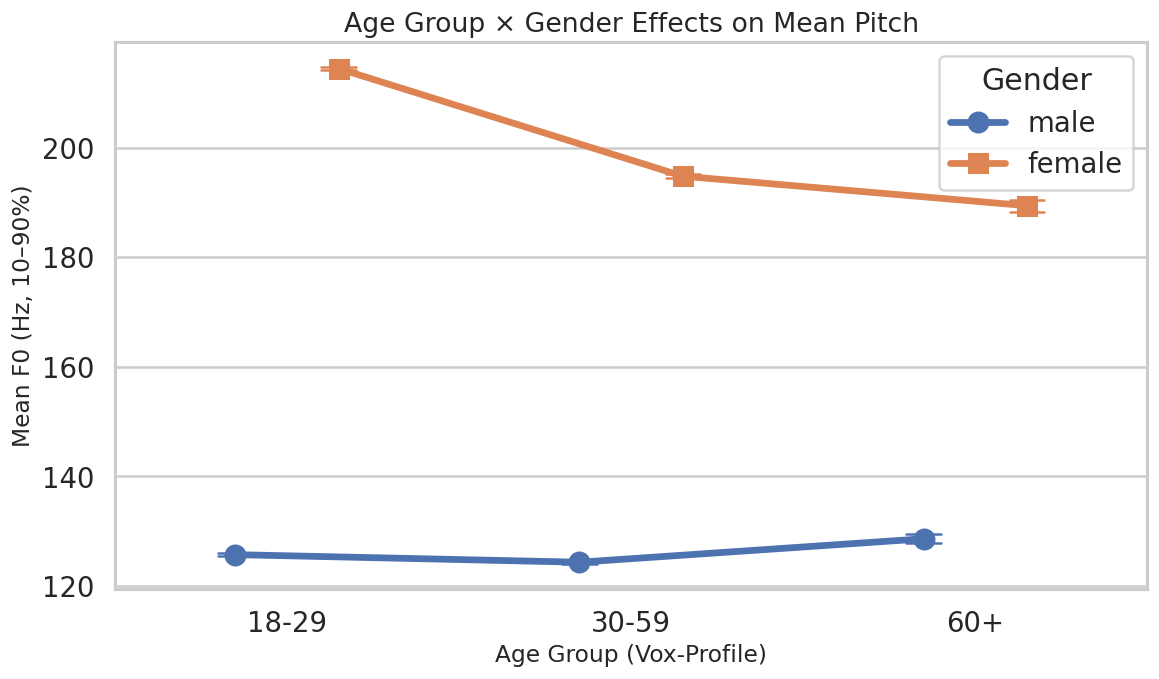

In [ ]:
plt.figure(figsize=(10, 6))

sns.pointplot(
    data=df_dem_age,
    x="age_group",
    y="f0_mean_p10_p90",
    hue="gender",
    dodge=0.3,
    markers=["o", "s"],
    capsize=0.1,
    errwidth=1.5
)

plt.xlabel("Age Group (Vox-Profile)")
plt.ylabel("Mean F0 (Hz, 10–90%)")
plt.title("Age Group × Gender Effects on Mean Pitch")
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

In [10]:
for g in df_dem["gender"].unique():
    sub = df_dem[df_dem["gender"] == g]
    r, p = pearsonr(sub["age_years"], sub["f0_mean_p10_p90"])
    print(f"{g}: r = {r:.3f}, p = {p:.2e}")

male: r = -0.046, p = 4.93e-32
female: r = -0.322, p = 0.00e+00


Age exhibits a modest but systematic relationship with pitch,
with distinct trajectories for different genders.

This pattern motivates explicit age × gender interaction analysis.

## 2.3 Age × Gender Interaction

Age-related pitch change is known to differ by gender due to:
- Hormonal effects
- Physiological aging of the vocal folds

We visualize interaction effects without imposing parametric assumptions.

In [13]:
# plt.figure(figsize=(9, 6))

# for g, color in zip(["male", "female"], ["blue", "red"]):
#     sub = df_dem[df_dem["gender"] == g]
#     sns.regplot(
#         x=sub["age_years"],
#         y=sub["f0_mean_p10_p90"],
#         scatter=False,
#         label=g,
#         color=color,
#         lowess=True
#     )

# plt.xlabel("Age (years)")
# plt.ylabel("Mean F0 (Hz, 10-90%)")
# plt.title("Age x Gender Interaction in Mean F0")
# plt.legend()
# plt.tight_layout()
# plt.show()

In [14]:
group_stats = (
    df_dem_age
    .groupby(["age_group", "gender"])
    .agg(
        mean_f0=("f0_mean_p10_p90", "mean"),
        std_f0=("f0_mean_p10_p90", "std"),
        n=("f0_mean_p10_p90", "count")
    )
    .reset_index()
)

display(group_stats)

,age_group,gender,mean_f0,std_f0,n
0,18-29,female,214.451198,26.590519,21629
1,18-29,male,125.719512,22.363060,26169
2,30-59,female,194.804444,27.302091,31692
3,30-59,male,124.338042,23.548307,32291
4,60+,female,189.419596,25.854172,2254
5,60+,male,128.617199,26.566739,3998


The interaction between age and gender reveals
distinct lifespan pitch trajectories.

This supports treating demographic effects as structured,
not merely categorical.

## Summary: Demographic Effects

Key findings:

- Mean F0 robustly separates genders
- Age exhibits continuous, gender-specific trends
- Pitch variability changes systematically with age
- Robust metrics enable fine-grained demographic analysis

These results establish a demographic baseline for social and interactional analyses in subsequent notebooks.